In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.20.0


Spirals val_acc: 0.6021


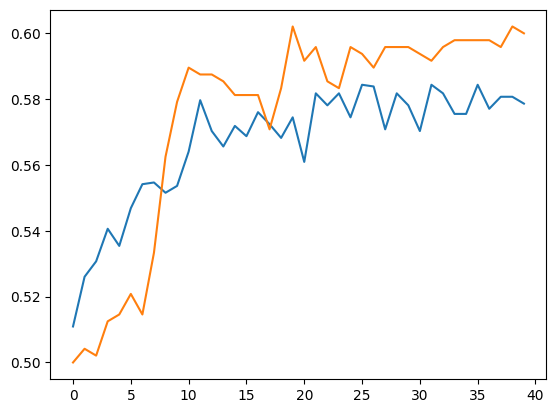

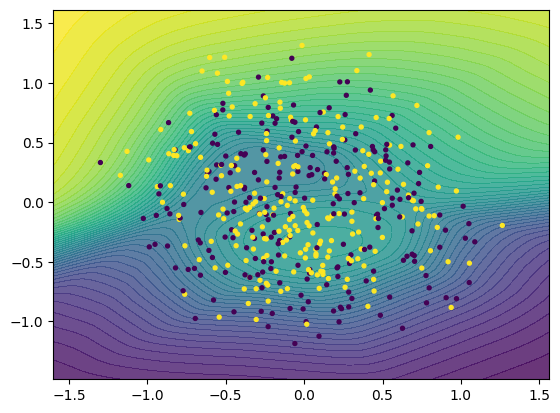

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8985 - loss: 0.3470 - val_accuracy: 0.9655 - val_loss: 0.1202 - learning_rate: 0.0010
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9610 - loss: 0.1294 - val_accuracy: 0.9712 - val_loss: 0.0991 - learning_rate: 0.0010
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9731 - loss: 0.0889 - val_accuracy: 0.9760 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9788 - loss: 0.0669 - val_accuracy: 0.9773 - val_loss: 0.0757 - learning_rate: 0.0010
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9829 - loss: 0.0542 - val_accuracy: 0.9792 - val_loss: 0.0735 - learning_rate: 0.0010
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9860 - loss: 0.0441 - val_accuracy: 0.9797 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━

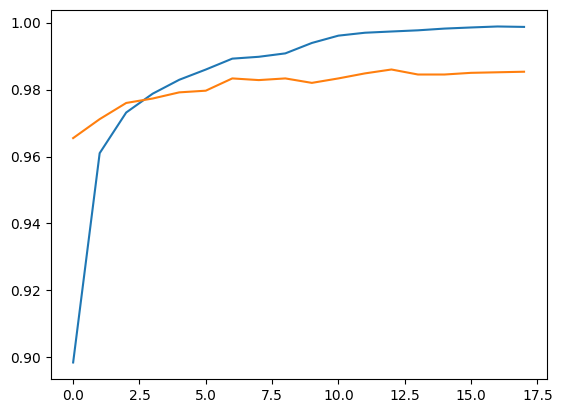

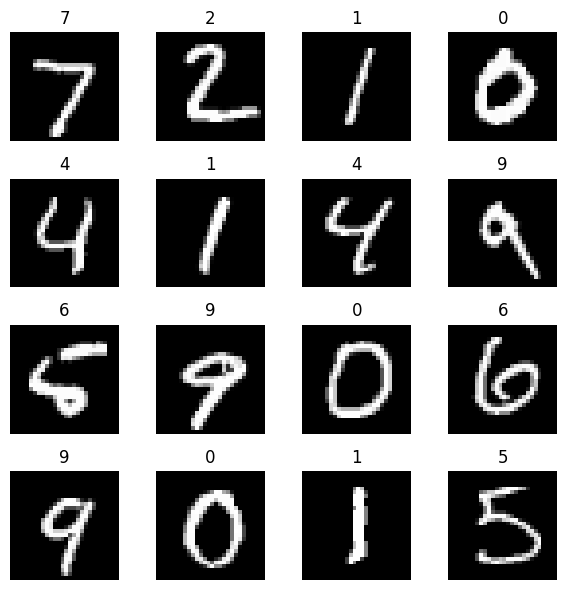

In [2]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.random.set_seed(42)
np.random.seed(42)

def make_mlp(input_dim, hidden=(128, 128, 64), dropout=0.0, l2=0.0, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for h in hidden:
        if l2 > 0:
            model.add(layers.Dense(h, activation="relu", kernel_regularizer=keras.regularizers.l2(l2)))
        else:
            model.add(layers.Dense(h, activation="relu"))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

def make_two_spirals(n_per_class=1000, noise=0.25):
    n = n_per_class
    t = np.linspace(0, 4 * np.pi, n)
    r = np.linspace(0.2, 1.0, n)

    x1 = np.c_[r * np.cos(t), r * np.sin(t)]
    x2 = np.c_[r * np.cos(t + np.pi), r * np.sin(t + np.pi)]

    X = np.vstack([x1, x2]).astype(np.float32)
    y = np.hstack([np.zeros(n), np.ones(n)]).astype(np.float32)

    X += np.random.normal(scale=noise, size=X.shape).astype(np.float32)

    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

X, y = make_two_spirals(n_per_class=1200, noise=0.20)

split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

spiral_model = make_mlp(
    input_dim=2,
    hidden=(256, 256, 128, 64),
    dropout=0.10,
    l2=1e-5,
    lr=1e-3
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5),
]

hist = spiral_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=128,
    verbose=0,
    callbacks=callbacks
)

val_loss, val_acc = spiral_model.evaluate(X_val, y_val, verbose=0)
print(f"Spirals val_acc: {val_acc:.4f}")

plt.figure()
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.show()

def plot_decision_boundary(model, X, y, steps=300, pad=0.3):
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xs = np.linspace(x_min, x_max, steps)
    ys = np.linspace(y_min, y_max, steps)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    preds = model.predict(grid, verbose=0).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, preds, levels=50, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=8)
    plt.show()

plot_decision_boundary(spiral_model, X_val, y_val)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28 * 28)
x_test  = x_test.reshape(-1, 28 * 28)

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)

mnist_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax"),
])

mnist_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

mnist_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

mnist_hist = mnist_model.fit(
    x_train, y_train_oh,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    verbose=1,
    callbacks=mnist_callbacks
)

test_loss, test_acc = mnist_model.evaluate(x_test, y_test_oh, verbose=0)
print(f"MNIST test_acc: {test_acc:.4f}")

plt.figure()
plt.plot(mnist_hist.history["accuracy"])
plt.plot(mnist_hist.history["val_accuracy"])
plt.show()

pred = np.argmax(mnist_model.predict(x_test[:16], verbose=0), axis=1)

plt.figure(figsize=(6, 6))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    ax.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"{pred[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()